# Préparation des données pour le Machine Learning

Ce notebook guide étape par étape le processus de nettoyage des données des arbres de Grenoble pour prédire l'année de plantation.

## Objectif
Préparer les données pour entraîner un modèle de Machine Learning qui pourra prédire l'année de plantation des arbres manquantes.

## Plan du notebook
1. Import des bibliothèques et chargement des données
2. Exploration initiale des données
3. Nettoyage des données
4. Sauvegarder en pikle les données

## 1. Import des bibliothèques et chargement des données

Nous utilisons plusieurs bibliothèques Python essentielles pour l'analyse de données :
- pandas : pour la manipulation des données
- numpy : pour les calculs numériques
- matplotlib et seaborn : pour la visualisation
- sklearn : pour la préparation des données pour le ML

In [80]:
# Les libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os

In [81]:
# Chargement des données
df = pd.read_csv('data/arbres_grenoble_epsg4326.csv', sep=',', encoding='utf-8')

# Affichage des premières lignes
print('Aperçu des données :')
display(df.head())

# Informations sur le dataset
print('\nInformations sur le dataset :')
display(df.info())

Aperçu des données :


,elem_point_id,code,nom,genre,genre_desc,categorie,categorie_desc,sous_categorie,sous_categorie_desc,code_parent,...,diametrearbre,causeabattage,collectivite,stationmetro,hauteurarbre,portarbre,structure,forme,typenature,geo_point_2d
0,34835,ESP36318,AR36318,VEG,VEGETATION,ESP01,Arbre,ESP151,Arbre de voirie,ESP237,...,NaN,NaN,Grenoble Alpes Métropole,NaN,NaN,NaN,Métropole de Grenoble,NaN,NaN,"45.167098421885385,5.740131798404362"
1,34836,ESP36319,AR36319,VEG,VEGETATION,ESP01,Arbre,ESP151,Arbre de voirie,ESP237,...,NaN,NaN,Grenoble Alpes Métropole,NaN,NaN,NaN,Métropole de Grenoble,NaN,NaN,"45.16710682038838,5.740199792549315"
2,34837,ESP36320,AR36320,VEG,VEGETATION,ESP01,Arbre,ESP151,Arbre de voirie,ESP237,...,NaN,NaN,Grenoble Alpes Métropole,NaN,NaN,NaN,Métropole de Grenoble,NaN,NaN,"45.167115270975415,5.740265608803635"
3,34838,ESP36321,AR36321,VEG,VEGETATION,ESP01,Arbre,ESP151,Arbre de voirie,ESP237,...,NaN,NaN,Grenoble Alpes Métropole,NaN,NaN,NaN,Métropole de Grenoble,NaN,NaN,"45.16712715617142,5.740349032579623"
4,34839,ESP36322,AR36322,VEG,VEGETATION,ESP01,Arbre,ESP151,Arbre de voirie,ESP237,...,NaN,NaN,Grenoble Alpes Métropole,NaN,NaN,NaN,Métropole de Grenoble,NaN,NaN,"45.167144245872265,5.740471081600832"



Informations sur le dataset :
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31670 entries, 0 to 31669
Data columns (total 38 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   elem_point_id          31670 non-null  int64  
 1   code                   31670 non-null  object 
 2   nom                    31670 non-null  object 
 3   genre                  31670 non-null  object 
 4   genre_desc             31670 non-null  object 
 5   categorie              31670 non-null  object 
 6   categorie_desc         31670 non-null  object 
 7   sous_categorie         31670 non-null  object 
 8   sous_categorie_desc    31670 non-null  object 
 9   code_parent            31670 non-null  object 
 10  code_parent_desc       31670 non-null  object 
 11  adr_secteur            31670 non-null  int64  
 12  bien_reference         31670 non-null  object 
 13  genre_bota             30859 non-null  object 
 14  espece                 

None

## 2. Exploration initiale des données

Avant de commencer le nettoyage, il est crucial de comprendre nos données :
- Quelles sont les colonnes disponibles ?
- Quels types de données avons-nous ?
- Y a-t-il des valeurs manquantes ?

In [82]:
# affichage des colonnes disponibles
print('\nColonnes disponibles :')
display(df.columns)
# affichage des type de données
print('\nTypes de données :')
display(df.dtypes)
# affichage si il y a des valeurs manquantes
print('\nValeurs manquantes :')
display(df.isnull().sum())



Colonnes disponibles :


Index(['elem_point_id', 'code', 'nom', 'genre', 'genre_desc', 'categorie',
       'categorie_desc', 'sous_categorie', 'sous_categorie_desc',
       'code_parent', 'code_parent_desc', 'adr_secteur', 'bien_reference',
       'genre_bota', 'espece', 'variete', 'stadededeveloppement', 'equipe',
       'remarques', 'anneedeplantation', 'raisondeplantation',
       'traitementchenilles', 'courrier', 'identifiantplu',
       'typeimplantationplu', 'intituleprotectionplu', 'anneeabattage',
       'essouchement', 'diametrearbre', 'causeabattage', 'collectivite',
       'stationmetro', 'hauteurarbre', 'portarbre', 'structure', 'forme',
       'typenature', 'geo_point_2d'],
      dtype='object')


Types de données :


elem_point_id              int64
code                      object
nom                       object
genre                     object
genre_desc                object
categorie                 object
categorie_desc            object
sous_categorie            object
sous_categorie_desc       object
code_parent               object
code_parent_desc          object
adr_secteur                int64
bien_reference            object
genre_bota                object
espece                    object
variete                   object
stadededeveloppement      object
equipe                   float64
remarques                 object
anneedeplantation        float64
raisondeplantation        object
traitementchenilles       object
courrier                 float64
identifiantplu           float64
typeimplantationplu       object
intituleprotectionplu     object
anneeabattage            float64
essouchement             float64
diametrearbre            float64
causeabattage            float64
collectivi


Valeurs manquantes :


elem_point_id                0
code                         0
nom                          0
genre                        0
genre_desc                   0
categorie                    0
categorie_desc               0
sous_categorie               0
sous_categorie_desc          0
code_parent                  0
code_parent_desc             0
adr_secteur                  0
bien_reference               0
genre_bota                 811
espece                    2300
variete                  27071
stadededeveloppement      4174
equipe                   31670
remarques                26358
anneedeplantation         2144
raisondeplantation       28383
traitementchenilles      29604
courrier                 31670
identifiantplu           31083
typeimplantationplu      26702
intituleprotectionplu    31083
anneeabattage            31670
essouchement             31670
diametrearbre            31670
causeabattage            31670
collectivite               718
stationmetro             29788
hauteura

### Visualisation des valeurs manquantes

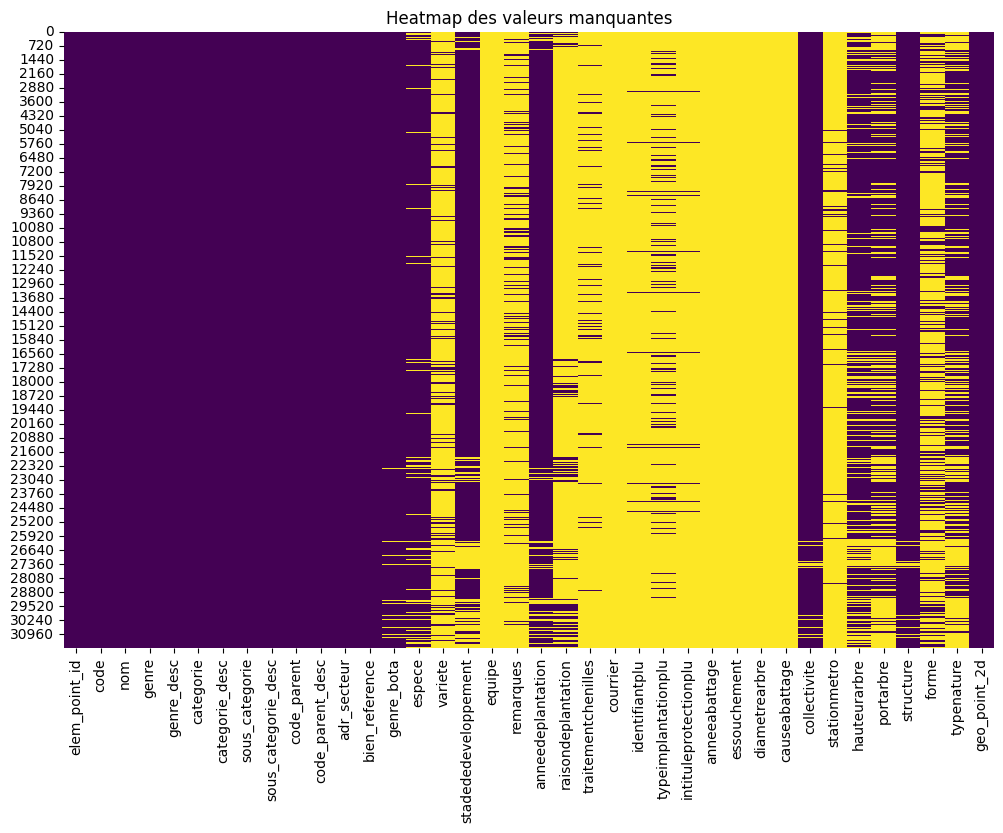

In [83]:
# Création d'une heatmap des valeurs manquantes
plt.figure(figsize=(12, 8))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title('Heatmap des valeurs manquantes')
plt.show()


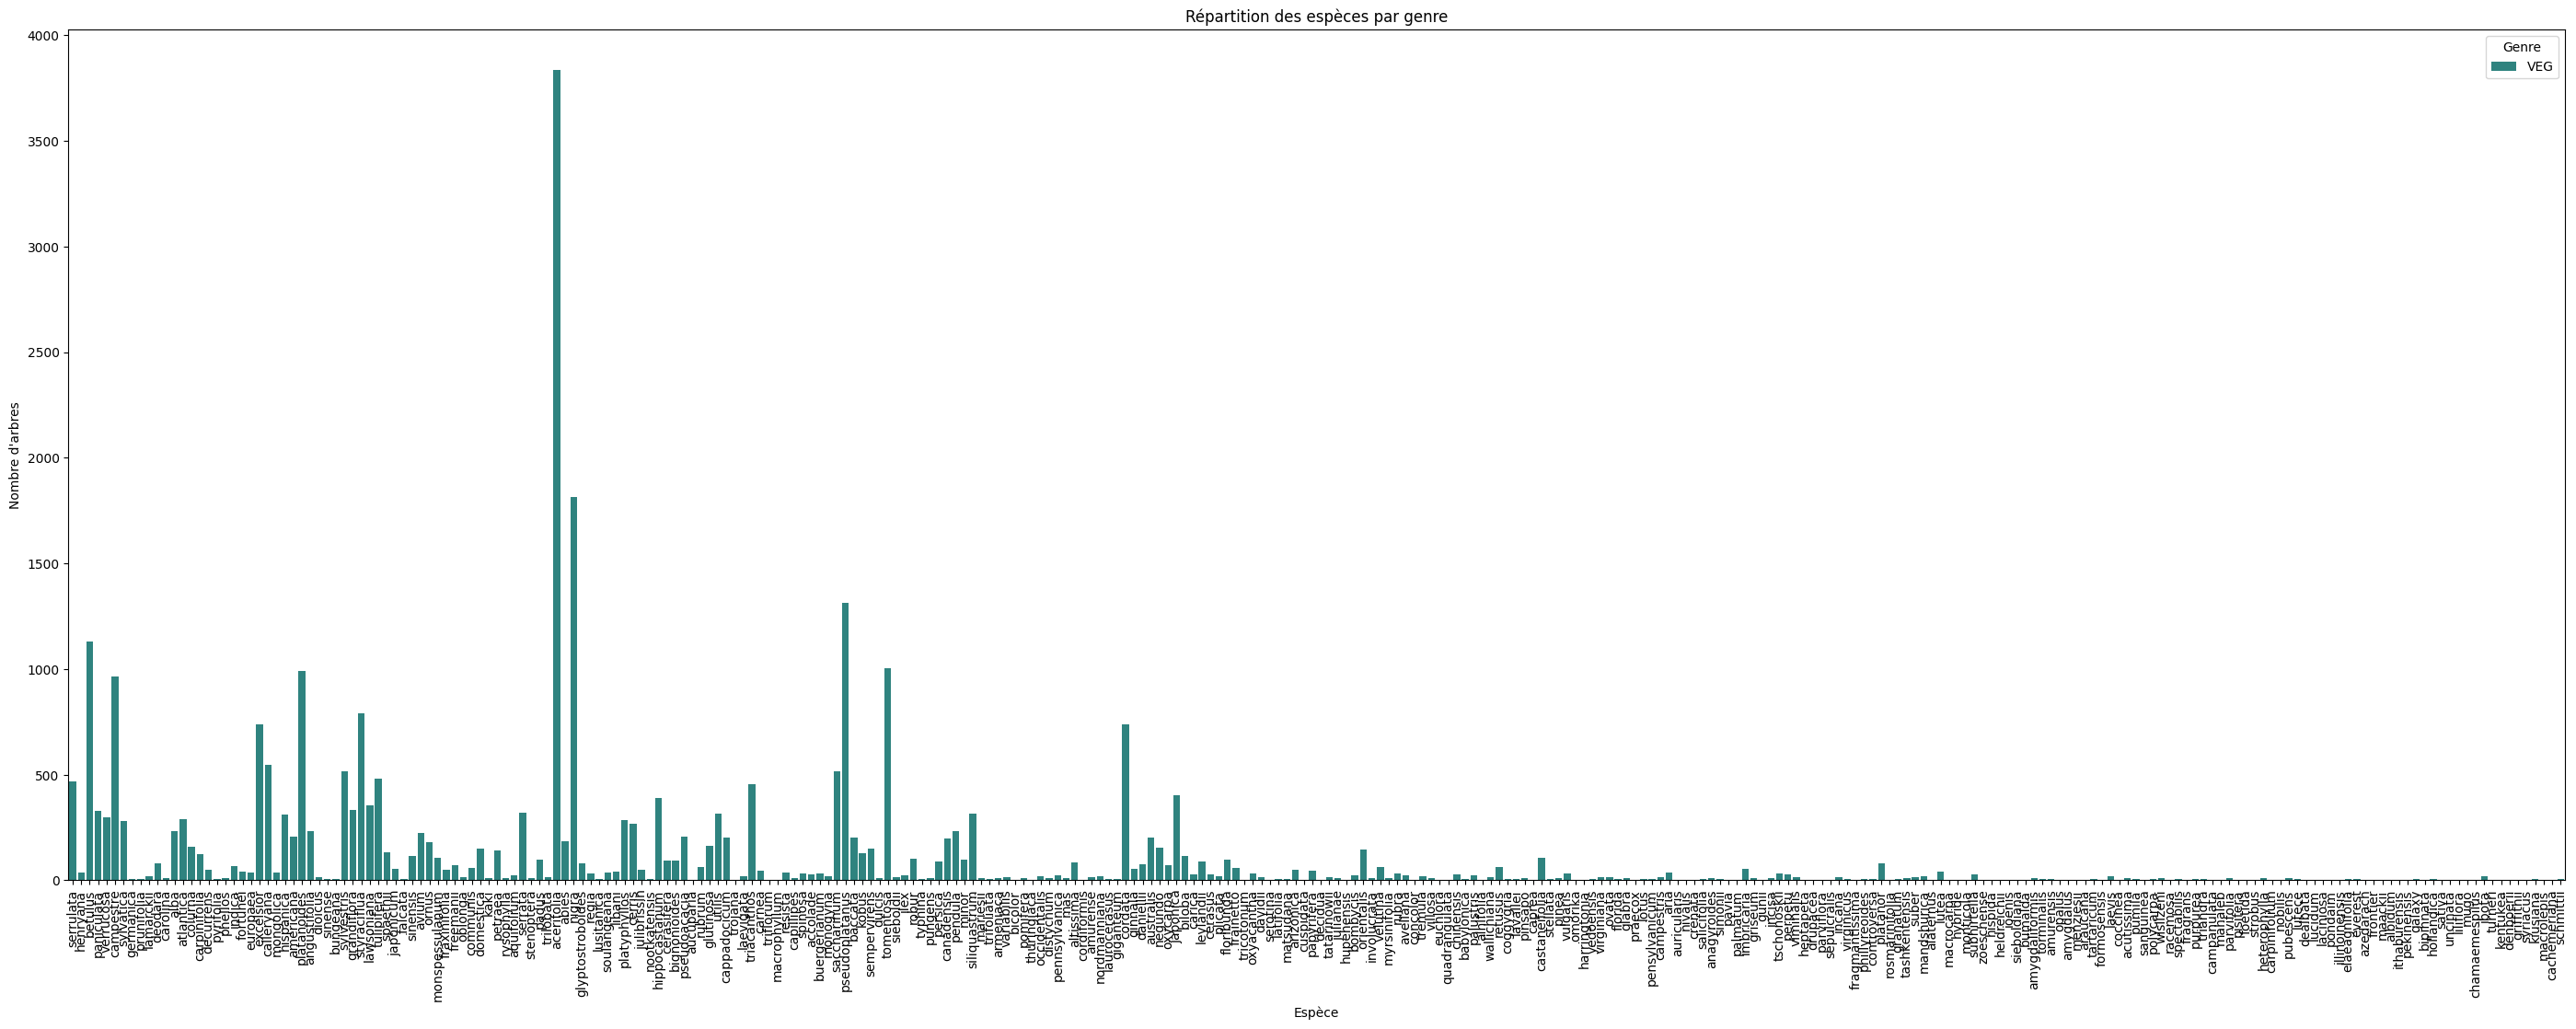

In [84]:
# Création avec des bars hue
plt.figure(figsize=(35, 12))
sns.countplot(data=df, x='espece', hue='genre', palette='viridis')
plt.title('Répartition des espèces par genre')
plt.xticks(rotation=90)
plt.xlabel('Espèce')
plt.ylabel('Nombre d\'arbres')
plt.legend(title='Genre')
plt.show()



## 3. Nettoyage des données

Après l'analyse initiale, nous allons :
1. Suppression des lignes sans année de plantation
2. Supprimer les colonnes non pertinentes pour la prédiction
3. Extraire les coordonnées géographiques

In [85]:
# 3.1 Suppression des lignes sans année de plantation

### 🔍 3.2 Nettoyage des colonnes inutiles

Nous allons :

- Supprimer les colonnes contenant plus de **40 % de valeurs manquantes**
- Supprimer les colonnes **trop spécifiques** (identifiants uniques par exemple), qui n’apportent pas d'information utile pour l'apprentissage automatique
- Supprimer les colonnes qui contiennent la même information ne sont pas utile

In [86]:
# 2 Supprimer les colonnes trop spécifiques, par exemple la colonne elem_point_id
# df = df.drop([elem_point_id])

In [87]:
# 3. Extraire les coordonnées géographiques, séparer latitude et longitude

## 5. Sauvegarde des données nettoyées en pikle

Nous sauvegardons les deux ensembles de données pour l'entraînement du modèle.

In [88]:
# Sauvegarde des données

## Conclusion

Nous avons effectué plusieurs étapes de nettoyage importantes :
1. Suppression des colonnes non pertinentes ou avec trop de valeurs manquantes
2. Extraction des coordonnées géographiques

Les données sont maintenant prêtes pour la suite du projet